In [2]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

shape    = (1, 100) # Nombre de píxels (Ny, Nz) a la pantalla.
y_range  = (0, 0)   # Rang en el pla equatorial del forat negre.
z_range  = (0, 10)  # Rang en la direcció de l'eix de rotació.
M        = 1        # Massa del forat negre.

# Definim alguns radis significatius
r_horizon = 2 * M
r_shadow  = 3 * np.sqrt(3) * M 
r_ISCO    = 6 * M
r_disk    = 12 #18

# Angle de 0 a 2pi, que serà útil per dibuixar cercles.
contour  = np.linspace(0, 2 * np.pi, 100)

In [ ]:
# per aefgir angle de la pantalla, s'ha e fer la rotacio de les posicions i le velocitats . canviar np amb cp pero al final fer cp.assnumpy pk matlpotlip  nomes funciona amb numpy

In [3]:
# Definim les coordenades (t, x, y, z) inicials de l'eixam. 
t_screen = 0.0
x_screen = 20.0
y_screen = np.linspace(*y_range, shape[0])[:, None]
z_screen = np.linspace(*z_range, shape[1])[None, :]

# Passem a coordenades esfèriques, per la mètrica de Schwarzschild.
t  = t_screen
r  = np.sqrt(x_screen**2 + y_screen**2 + z_screen**2)
th = np.arccos(z_screen / r)
ph = np.arctan2(y_screen, x_screen)

# Posem primer les components espacials de la 4-velocitat, alineada amb l'eix x.
# Aquestes expressions són les components de - d/dx en coordenades esfèriques.
#posar primer dx i dz calculats amb el notebook mathematica i calcular la resta amb aixo.


#buscar on divideix per sin th pk pot ser 0, tot i això es soluciona augmentan el dl = 0.01


dr_dl  = - np.sin(th) * np.cos(ph)
dth_dl = - np.cos(th) * np.cos(ph) / r
dph_dl = + np.sin(ph) / (r * np.sin(th))

# Ara normalitzem per tal que dt / dlambda = 1 i la 4-velocitat sigui nul·la.
norm2  = dr_dl**2 / (1 - 2 * M / r) + r**2 * (dth_dl**2 + np.sin(th)**2 * dph_dl**2)
factor = np.sqrt(norm2 / (1 - 2*M / r))

# Definim un eixam de fotons sobre la pantalla, amb els que farem el ray tracing.
swarm_init = np.zeros(shape + (8,))

swarm_init[..., 0] = t
swarm_init[..., 1] = r
swarm_init[..., 2] = th
swarm_init[..., 3] = ph

swarm_init[..., 4] = 1
swarm_init[..., 5] = dr_dl  / factor
swarm_init[..., 6] = dth_dl / factor
swarm_init[..., 7] = dph_dl / factor

# Comprovem que la 4-velocitat és efectivament nul·la
np.allclose(- (1 - 2 * M / r) * swarm_init[..., 4]**2 + swarm_init[..., 5]**2 / (1 - 2 * M / r) + \
            r**2 * (swarm_init[..., 6]**2 + np.sin(th)**2 * swarm_init[..., 7]**2), 0)

True

In [9]:
# Càlcul dels símbols de Christoffel, que es retornen amb la forma (Ny, Nz).
# Important: cal tenir en compte que són simètrics en els dos índexs de baix.

def christoffel(swarm, indices):
    # No necessitem la 4-velocitat per als Christoffels, la podem llençar
    _, r, th, ph, _, _, _, _  = swarm.transpose(2, 0, 1)

    if indices == (1, 0, 0):  # Γ^r_tt
        gamma = M * (r - 2 * M) / r**3

    elif (indices == (0, 0, 1)) or (indices == (0, 1, 0)):  # Γ^t_tr
        gamma = M / (r * (r - 2 * M))

    elif indices == (1, 1, 1):  # Γ^r_rr
        gamma = -M / (r * (r - 2 * M))

    elif indices == (1, 2, 2):  # Γ^r_θθ
        gamma = -(r - 2 * M)

    elif indices == (1, 3, 3):  # Γ^r_φφ
        gamma = -(r - 2 * M) * np.sin(th)**2

    elif (indices == (2, 1, 2)) or (indices == (2, 2, 1)):  # Γ^θ_rθ
        gamma = 1 / r

    elif indices == (2, 3, 3):  # Γ^θ_φφ
        gamma = -np.sin(th) * np.cos(th)

    elif (indices == (3, 1, 3)) or (indices == (3, 3, 1)):  # Γ^φ_rφ
        gamma = 1 / r

    elif (indices == (3, 2, 3)) or (indices == (3, 3, 2)):  # Γ^φ_θφ
        gamma = np.cos(th) / np.sin(th)

    else:
        gamma = None

    return gamma


In [10]:
# Funció que calculi la derivada de l'array swarm respecte 
# al paràmetre afí a partir de l'equació geodèsica.

def geoeq(swarm):
    
    dswarm = np.zeros_like(swarm) 
    dswarm[..., :4] = swarm[..., 4:]
    
    for idx1 in range(4):
        for idx2 in range(4):
            for idx3 in range(idx2, 4):
                gamma = christoffel(swarm, (idx1, idx2, idx3))
                if gamma is not None:
                    # Sumem dues vegades els termes amb índexs diferents, per la simetria dels símbols de Christoffel.
                    dswarm[..., idx1 + 4] -= (2 - (idx2 == idx3)) * gamma * swarm[..., idx2 + 4] * swarm[..., idx3 + 4]

    dswarm[stopped_mask, :] = 0.0
    return dswarm

# Funció que comprova la posició de cada fotó i actualitza
# les màscares que es faran servir en l'evolució.

def update_masks(swarm, new_swarm):

    _, r, th, _, _, _, _, _    = swarm.transpose(2, 0, 1)
    _, _, n_th, _, _, _, _, _  = new_swarm.transpose(2, 0, 1)
    
    fell_into_horizon[r <= 1.1 * r_horizon] = True
    went_too_far[r > 30] = True
    
    crossed_the_equator = np.cos(th) * np.cos(n_th) < 0
    hit_the_disk[crossed_the_equator & (r > r_ISCO) & (r < r_disk)] = True
    
    stopped_mask[fell_into_horizon | went_too_far | hit_the_disk] = True
    
# Integrador Runge-Kutta 4 que aprofita la funció anterior per 
# evolucionar l'array swarm un pas de paràmetre afí dlam.

def RK4(lam, swarm):
    k1 = geoeq(swarm)
    k2 = geoeq(swarm + 0.5 * k1 * dlam)
    k3 = geoeq(swarm + 0.5 * k2 * dlam)
    k4 = geoeq(swarm + k3 * dlam)

    new_lam   = lam + dlam
    new_swarm = swarm + dlam * (k1 + 2*k2 + 2*k3 + k4) / 6

    update_masks(swarm, new_swarm)
    
    return new_lam, new_swarm

# Funció que converteix les coordenades de Schwarzschild en cartesianes
# per tal de poder dibuixar les trajectòries en matplotlib.

def toCartesian(swarm):
    _, r, th, ph, _, _, _, _  = swarm.transpose(2, 0, 1)
    x = r * np.sin(th) * np.cos(ph)
    y = r * np.sin(th) * np.sin(ph)
    z = r * np.cos(th)
    return x, y, z

In [11]:
# Posem el paràmetre afí lam = 0 per a tots els fotons.
lam, dlam = 0, 0.1

# Inicialitzem l'eixam de fotons i els arrays on guardar-lo.
swarm = swarm_init
xlist, _, zlist = toCartesian(swarm)

# Inicialitzem les màscares
fell_into_horizon = np.zeros_like(r, dtype = bool)
went_too_far      = np.zeros_like(r, dtype = bool)
hit_the_disk      = np.zeros_like(r, dtype = bool)
stopped_mask      = np.zeros_like(r, dtype = bool)

for it in tqdm(range(500)):  
    lam, swarm = RK4(lam, swarm)
    x, _, z    = toCartesian(swarm)
    xlist = np.vstack([xlist, x])
    zlist = np.vstack([zlist, z])

print(f'Paràmetre afí al final de la integració: {lam:.2f}')


100%|███████████████████████████████████████████| 500/500 [00:00<00:00, 993.57it/s]

Paràmetre afí al final de la integració: 50.00


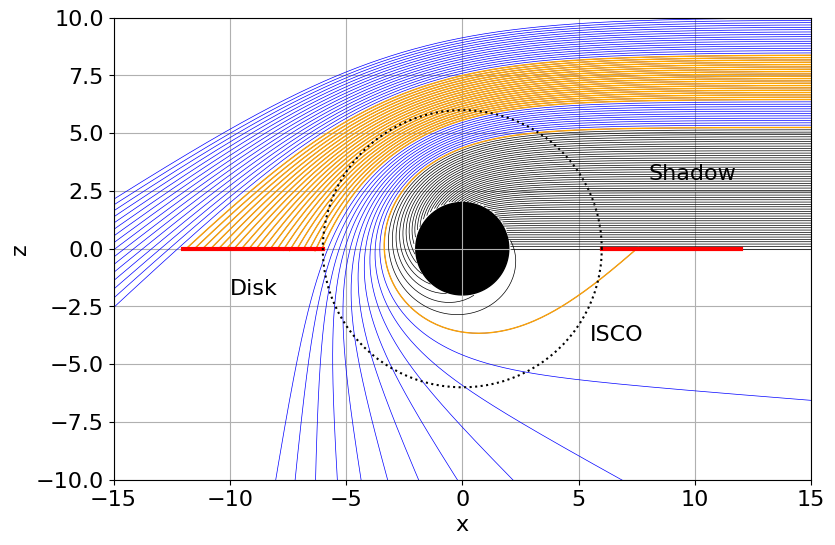

In [12]:
fig, ax = plt.subplots(1, 1, figsize = (9, 6));
plt.rc('font', size = 16)

ax.plot(xlist[:, fell_into_horizon.ravel()],  zlist[:, fell_into_horizon.ravel()],  color = 'black', lw = 0.5)
ax.plot(xlist[:, ~fell_into_horizon.ravel()], zlist[:, ~fell_into_horizon.ravel()], color = 'blue', lw = 0.5)
ax.plot(xlist[:, hit_the_disk.ravel()],       zlist[:, hit_the_disk.ravel()],       color = 'orange', lw = 1)

ax.plot([-r_disk, -r_ISCO, np.nan, r_ISCO, r_disk], np.zeros(5),  color = 'red', lw = 3)
ax.fill(r_horizon * np.cos(contour), r_horizon * np.sin(contour), color = 'black')
ax.plot(r_ISCO * np.cos(contour), r_ISCO * np.sin(contour), ls = ':', color = 'black')

ax.text(8, 3, 'Shadow')
ax.text(-10, -2, 'Disk')
ax.text(5.5, -4, 'ISCO')
ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_xlim(-15,15)
ax.set_ylim(-10,10)
ax.grid()

In [13]:
#per pintar imshow posar interpolation pk t'omple punts